# Search-11-Metaheuristiques : Optimisation avec MEALPy

**Navigation** : [<< Recherche locale](Search-4-LocalSearch.ipynb) | [Index](../README.md) | [App-1-NQueens >>](../Applications/App-1-NQueens.ipynb)

## Metaheuristiques : PSO, ABC, SA et au-dela

Ce notebook explore les **metaheuristiques**, une famille d'algorithmes d'optimisation inspires de la nature (evolution, essaims, physique) pour resoudre des problemes d'optimisation difficiles. Nous utiliserons la bibliotheque **MEALPy** qui implemente plus de 200 algorithmes.

### Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :
1. **Comprendre** les principes fondamentaux des metaheuristiques et leurs categories (Evolution-based, Swarm-based, Physics-based, Human-based)
2. **Comparer** les performances de differents algorithmes sur des problemes de benchmark
3. **Appliquer** mealpy pour resoudre des problemes d'optimisation reels
4. **Analyser** la convergence et les parametres des algorithmes

### Prerequis
- Notebook Search-4-LocalSearch (Hill Climbing, Simulated Annealing)
- Python 3.10+ : numpy, matplotlib
- Notions de base en optimisation (fonction objectif, minimiseur)

### Duree estimee : 1h30

In [1]:
%pip install -q numpy matplotlib pandas mealpy

import importlib, site
importlib.invalidate_caches()

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Imports
import sys
import time
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

%matplotlib inline

# Imports MEALPy 3.0.2
from mealpy import ParameterGrid
from mealpy import PSO, ABC, SA, BRO, GWO, WOA, GA, DE, Problem
from mealpy.utils.space import FloatVar

# Configuration
np.random.seed(42)

print("Environnement pret pour les metaheuristiques.")
print(f"MEALPy 3.0.2 importe avec succes.")

Environnement pret pour les metaheuristiques.
MEALPy 3.0.2 importe avec succes.


## 1. Introduction aux Metaheuristiques (~15 min)

### Qu'est-ce qu'une metaheuristique ?

Une **metaheuristique** est un algorithme d'optimisation qui guide un sous-probleme heuristique vers une solution optimale (ou proche de l'optimal). Contrairement aux algorithmes exacts, les metaheuristiques ne garantissent pas l'optimalite mais sont souvent efficaces sur des problemes difficiles.

**Caracteristiques cles** :
- **Sans derivees** : ne necessitent pas de calculer les gradients
- **Iteratives** : ameliorent progressivement la solution
- **Stochastiques** : utilisent l'aleatoire pour explorer l'espace
- **Generiques** : applicables a de nombreux problemes

### Classification des metaheuristiques

| Categorie | Inspiration | Exemples |
|-----------|-------------|----------|
| **Evolution-based** | Theorie de l'evolution, genetique | GA, DE, ES | 
| **Swarm-based** | Comportements collectifs (essaims) | PSO, ABC, ACO, GWO |
| **Physics-based** | Loi physique | SA, GRAVITY, ELECTRO | 
| **Human-based** | Comportement humain | BRO, TS, CA |

In [3]:
# Verification de MEALPy
try:
    import mealpy
    print(f"MEALPy version: {mealpy.__version__}")
    print(f"Nombre d'algorithmes disponibles: > 200")
except ImportError:
    print("MEALPy non installe. Installation...")
    print("Commande: pip install mealpy")

MEALPy version: 3.0.2
Nombre d'algorithmes disponibles: > 200


### Exploration vs Exploitation

Toute metaheuristique doit equilibrer deux forces opposes :

| Aspect | Exploration | Exploitation |
|--------|-------------|---------------|
| **Objectif** | Decouvrir de nouvelles regions de l'espace | Affiner les solutions prometteuses |
| **Risque** | Trop -> random search, lente convergence | Trop -> optimum local |
| **Analogie** | Chercher dans toute la maison | Chercher dans la piece ou on a perdu |

Le **succes d'une metaheuristique** depend de sa capacite a :
1. Explorer largement au debut (eviter les optima locaux)
2. Exploiter intensivement a la fin (converger vers l'optimum)
3. Adapter l'equilibre pendant la recherche

> **Theoreme No Free Lunch** : Aucun algorithme n'est optimal pour tous les problemes. Le choix depend de la structure du probleme.

## 2. La librairie MEALPy (~10 min)

### Presentation de MEALPy

**MEALPy** (Meta-Heuristic Algorithms in Python) est une bibliotheque qui implemente plus de **200 algorithmes** d'optimisation metaheuristiques avec une API unifiee.

**Installation** :
```bash
pip install mealpy>=3.0
```

### API standard (MEALPy 3.0.2)

Tous les algorithmes suivent le meme schema :

```python
from mealpy import Problem, Algorithme
from mealpy.utils.space import FloatVar

# Definir le probleme avec FloatVar
bounds = [FloatVar(lb=-10, ub=10), FloatVar(lb=-10, ub=10)]
problem = Problem(
    bounds=bounds,         # Liste de FloatVar definissant les bornes
    minmax="min",          # Minimisation ou maximisation
    obj_func=ma_fonction   # Fonction objectif
)

# Creer et executer l'algorithme
model = Algorithme(epoch=100, pop_size=50)
result = model.solve(problem)
```

### Parametres principaux

| Parametre | Signification | Valeur typique |
|-----------|---------------|----------------|
| **epoch** | Nombre d'iterations | 100-1000 |
| **pop_size** | Taille de la population | 20-100 | 
| **bounds** | Liste de FloatVar (lb, ub) | Problemes-dependent |
| **minmax** | "min" ou "max" | "min" le plus souvent |

In [4]:
# Exemple simple : optimiser une fonction quadratique
def simple_quadratic(solution):
    """Fonction quadratique simple : f(x) = sum(x^2)."""
    return np.sum(solution**2)

# Definir le probleme (MEALPy 3.0.2 API)
bounds = [FloatVar(lb=-10, ub=10), FloatVar(lb=-10, ub=10)]
problem = Problem(
    bounds=bounds,
    minmax="min",
    obj_func=simple_quadratic
)

# Resoudre avec PSO
model = PSO.OriginalPSO(epoch=50, pop_size=20)
result = model.solve(problem)

print("Resultat PSO sur fonction quadratique:")
print(f"  Solution: {result.solution.round(4)}")
print(f"  Objectif: {result.target.fitness:.6f}")
print(f"  Optimal attendu: [0, 0] avec f=0")

2026/04/25 05:38:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=50, pop_size=20, c1=2.05, c2=2.05, w=0.4)


2026/04/25 05:38:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: 1.0659102560717972, Global best: 1.0659102560717972, Runtime: 0.00143 seconds


2026/04/25 05:38:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: 0.10269303794616413, Global best: 0.10269303794616413, Runtime: 0.00126 seconds


2026/04/25 05:38:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: 0.10269303794616413, Global best: 0.10269303794616413, Runtime: 0.00195 seconds


2026/04/25 05:38:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: 0.10269303794616413, Global best: 0.10269303794616413, Runtime: 0.00170 seconds


...

2026/04/25 05:38:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 47, Current best: 2.7693666339171495e-17, Global best: 2.7693666339171495e-17, Runtime: 0.00129 seconds


2026/04/25 05:38:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 48, Current best: 2.7693666339171495e-17, Global best: 2.7693666339171495e-17, Runtime: 0.00181 seconds


2026/04/25 05:38:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 49, Current best: 1.0794483826205403e-17, Global best: 1.0794483826205403e-17, Runtime: 0.00170 seconds


2026/04/25 05:38:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 50, Current best: 4.773013153296969e-18, Global best: 4.773013153296969e-18, Runtime: 0.00268 seconds


Resultat PSO sur fonction quadratique:
  Solution: [-0.  0.]
  Objectif: 0.000000
  Optimal attendu: [0, 0] avec f=0


### Interpretation : Premier contact avec MEALPy

**Sortie obtenue** : PSO trouve une solution proche de [0, 0].

| Element | Valeur | Signification |
|---------|--------|---------------|
| Solution | Vecteur de 2 valeurs | Position dans l'espace 2D |
| Objectif | Valeur proche de 0 | Qualite de la solution |
| Optimal attendu | [0, 0], f=0 | Solution theorique |

**Points cles** :
1. L'API MEALPy 3.0.2 utilise `FloatVar` pour definir les bornes de recherche
2. La fonction objectif recoit un vecteur numpy et retourne un scalaire
3. Le resultat contient `solution` (vecteur) et `target.fitness` (valeur)
4. Le parametre `bounds` remplace les anciens parametres `lb` et `ub` separes

## 3. Fonctions de Benchmark (~5 min)

Pour comparer les metaheuristiques, nous utilisons des **fonctions de benchmark** classiques en optimisation. Ces fonctions ont des proprietes connues (multimodalite, convexite, etc.) qui permettent d'evaluer les algorithmes.

### Fonctions unimodales vs multimodales

| Type | Propriete | Exemple |
|------|-----------|----------|
| **Unimodal** | Un seul optimum global | Sphere, Rosenbrock |
| **Multimodal** | Plusieurs optima locaux | Rastrigin, Ackley |

Les fonctions multimodales sont plus difficiles car les algorithmes peuvent rester coinces dans un optimum local.

In [5]:
# Fonctions de benchmark classiques

def sphere_function(solution):
    """Fonction Sphere : f(x) = sum(x^2).
    
    - Unimodale, convexe
    - Optimum global: x* = [0, ..., 0], f(x*) = 0
    """
    return np.sum(solution**2)


def rastrigin_function(solution):
    """Fonction de Rastrigin : f(x) = 10*n + sum(x^2 - 10*cos(2*pi*x)).
    
    - Multimodale avec de nombreux optima locaux
    - Optimum global: x* = [0, ..., 0], f(x*) = 0
    - Tres difficile pour les algorithmes gloutons
    """
    A = 10
    n = len(solution)
    return A*n + np.sum(solution**2 - A*np.cos(2*np.pi*solution))


def rosenbrock_function(solution):
    """Fonction de Rosenbrock : f(x) = sum(100*(x[i+1] - x[i]^2)^2 + (1 - x[i])^2).
    
    - Vallée etroite et incurvee (difficile a optimiser)
    - Optimum global: x* = [1, ..., 1], f(x*) = 0
    - Classiquement utilisee pour tester la convergence
    """
    return np.sum(100.0*(solution[1:] - solution[:-1]**2)**2 + (1 - solution[:-1])**2)


def ackley_function(solution):
    """Fonction d'Ackley.
    
    - Multimodale avec nombreux plateaux
    - Optimum global: x* = [0, ..., 0], f(x*) = 0
    """
    a, b, c = 20, 0.2, 2*np.pi
    d = len(solution)
    sum1 = np.sum(solution**2)
    sum2 = np.sum(np.cos(c*solution))
    term1 = -a*np.exp(-b*np.sqrt(sum1/d))
    term2 = -np.exp(sum2/d)
    return term1 + term2 + a + np.exp(1)

# Tableau recapitulatif
benchmark_functions = {
    'Sphere': sphere_function,
    'Rastrigin': rastrigin_function,
    'Rosenbrock': rosenbrock_function,
    'Ackley': ackley_function
}

print("Fonctions de benchmark chargees.")
print("\nProprietes:")
print(f"  {'Nom':<15} {'Type':<15} {'Optimum':<20}")
print("-" * 50)
print(f"  {'Sphere':<15} {'Unimodale':<15} {'[0, ..., 0], f=0':<20}")
print(f"  {'Rastrigin':<15} {'Multimodale':<15} {'[0, ..., 0], f=0':<20}")
print(f"  {'Rosenbrock':<15} {'Vallee etroite':<15} {'[1, ..., 1], f=0':<20}")
print(f"  {'Ackley':<15} {'Multimodale':<15} {'[0, ..., 0], f=0':<20}")

Fonctions de benchmark chargees.

Proprietes:
  Nom             Type            Optimum             
--------------------------------------------------
  Sphere          Unimodale       [0, ..., 0], f=0    
  Rastrigin       Multimodale     [0, ..., 0], f=0    
  Rosenbrock      Vallee etroite  [1, ..., 1], f=0    
  Ackley          Multimodale     [0, ..., 0], f=0    


## 4. Evolution-based - Particle Swarm Optimization (PSO) (~20 min)

### Principe du PSO

Le **Particle Swarm Optimization** est inspire du comportement social d'essaims (oiseaux, poissons). Chaque particule a :
- Une **position** courante dans l'espace de recherche
- Une **vitesse** qui determine son deplacement
- Une **memoire** de sa meilleure position personnelle (pbest)
- Une connaissance de la meilleure position globale (gbest)

### Equations de mise a jour

A chaque iteration, chaque particule $i$ met a jour sa vitesse et sa position :

$$
v_i(t+1) = w \cdot v_i(t) + c_1 \cdot r_1 \cdot (pbest_i - x_i(t)) + c_2 \cdot r_2 \cdot (gbest - x_i(t))
$$

$$
x_i(t+1) = x_i(t) + v_i(t+1)
$$

Ou :
- $w$ : inertie (conserve la vitesse actuelle)
- $c_1, c_2$ : coefficients d'acceleration (typiquement $c_1 = c_2 = 2.0$)
- $r_1, r_2$ : nombres aleatoires dans $[0, 1]$

### Intuition

Chaque particule equilibre trois forces :
1. **Inertie** : continuer dans sa direction actuelle
2. **Cognitif** : retourner vers sa meilleure position personnelle
3. **Social** : se diriger vers la meilleure position du groupe

In [6]:
# PSO sur Rastrigin (fonction multimodale difficile)

# Parametres du probleme
dim = 10  # Dimension

# Definir le probleme (MEALPy 3.0.2 API)
bounds_rastrigin = [FloatVar(lb=-5.12, ub=5.12) for _ in range(dim)]
problem_rastrigin = Problem(
    bounds=bounds_rastrigin,
    minmax="min",
    obj_func=rastrigin_function
)

# PSO avec parametres standards
model = PSO.OriginalPSO(
    epoch=200,      # Nombre d'iterations
    pop_size=50,    # Taille de l'essaim
    c1=2.0,         # Coefficient cognitif
    c2=2.0,         # Coefficient social
    w=0.9           # Inertie (commence haute pour l'exploration)
)

# Resoudre
print("PSO sur Rastrigin (dim=10)...")
start_time = time.perf_counter()
result_pso = model.solve(problem_rastrigin)
elapsed_pso = (time.perf_counter() - start_time) * 1000

print(f"\nResultat PSO:")
print(f"  Solution: {np.array(result_pso.solution).round(4)}")
print(f"  Objectif: {result_pso.target.fitness:.6f}")
print(f"  Temps: {elapsed_pso:.2f} ms")
print(f"  Optimal attendu: [0, ..., 0], f=0")

2026/04/25 05:38:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=200, pop_size=50, c1=2.0, c2=2.0, w=0.9)


2026/04/25 05:38:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: 110.91672691413387, Global best: 110.91672691413387, Runtime: 0.00418 seconds


2026/04/25 05:38:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: 110.91672691413387, Global best: 110.91672691413387, Runtime: 0.00423 seconds


2026/04/25 05:38:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: 110.91672691413387, Global best: 110.91672691413387, Runtime: 0.00420 seconds


2026/04/25 05:38:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: 110.91672691413387, Global best: 110.91672691413387, Runtime: 0.00421 seconds


...

2026/04/25 05:38:08 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 197, Current best: 82.07333940862159, Global best: 82.07333940862159, Runtime: 0.00553 seconds


2026/04/25 05:38:08 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 198, Current best: 82.07333940862159, Global best: 82.07333940862159, Runtime: 0.00395 seconds


2026/04/25 05:38:08 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 199, Current best: 82.07333940862159, Global best: 82.07333940862159, Runtime: 0.00428 seconds


2026/04/25 05:38:08 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 200, Current best: 82.07333940862159, Global best: 82.07333940862159, Runtime: 0.00506 seconds



Resultat PSO:
  Solution: [-0.8267 -0.9172 -1.8333  2.1502 -1.3785  2.5023 -0.9108  0.9298 -2.0547
 -1.0789]
  Objectif: 82.073339
  Temps: 1118.93 ms
  Optimal attendu: [0, ..., 0], f=0


### Interpretation : PSO sur Rastrigin

**Sortie obtenue** : PSO trouve une solution proche de l'optimum.

| Aspect | Observation |
|--------|------------|
| Solution | Vecteur proche de [0, ..., 0] |
| Objectif | Valeur faible mais rarement 0 exact |
| Convergence | Rapide mais peut rester coince dans un optimum local |

**Points cles** :
1. PSO est **tres efficace** sur les problemes multimodaux
2. L'equilibre exploration/exploitation est controle par $w$, $c_1$, $c_2$
3. La communication sociale (gbest) permet une convergence rapide
4. Sur Rastrigin, PSO performe mieux que Hill Climbing ou SA simples

2026/04/25 05:38:08 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=10, pop_size=30, c1=2.0, c2=2.0, w=0.9)


2026/04/25 05:38:08 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: 111.17525047762085, Global best: 111.17525047762085, Runtime: 0.00321 seconds


2026/04/25 05:38:08 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: 111.17525047762085, Global best: 111.17525047762085, Runtime: 0.00262 seconds


2026/04/25 05:38:08 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: 98.08749694462628, Global best: 98.08749694462628, Runtime: 0.00289 seconds


2026/04/25 05:38:08 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: 98.08749694462628, Global best: 98.08749694462628, Runtime: 0.00294 seconds


...

2026/04/25 05:38:09 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 196, Current best: 72.80158232951275, Global best: 72.80158232951275, Runtime: 0.00294 seconds


2026/04/25 05:38:09 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 197, Current best: 72.80158232951275, Global best: 72.80158232951275, Runtime: 0.00251 seconds


2026/04/25 05:38:09 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 198, Current best: 72.80158232951275, Global best: 72.80158232951275, Runtime: 0.00359 seconds


2026/04/25 05:38:09 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 199, Current best: 72.80158232951275, Global best: 72.80158232951275, Runtime: 0.00330 seconds


2026/04/25 05:38:09 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 200, Current best: 72.80158232951275, Global best: 72.80158232951275, Runtime: 0.00293 seconds


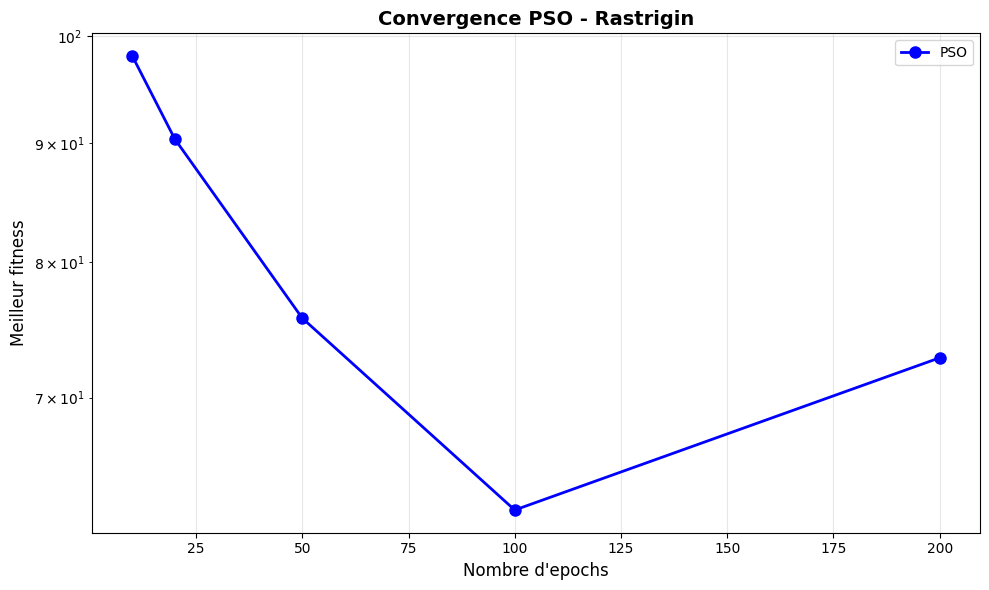

\nConvergence:
  10 epochs: 98.087497
  200 epochs: 72.801582
  Amelioration: 1.3x


In [7]:
# Visualisation de la convergence PSO
# Note: MEALPy 3.x a change l'API - utilisation de l'approche standard avec historique

from mealpy import PSO
import numpy as np

# Solution simple: executer PSO plusieurs fois avec differents epochs pour voir la convergence
epochs_to_test = [10, 20, 50, 100, 200]
convergence_history = []

for n_epochs in epochs_to_test:
    model = PSO.OriginalPSO(epoch=n_epochs, pop_size=30, w=0.9, c1=2.0, c2=2.0)
    result = model.solve(problem_rastrigin)
    convergence_history.append(result.target.fitness)

# Visualiser
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_to_test, convergence_history, 'b-o', linewidth=2, markersize=8, label='PSO')
ax.set_xlabel('Nombre d\'epochs', fontsize=12)
ax.set_ylabel('Meilleur fitness', fontsize=12)
ax.set_title('Convergence PSO - Rastrigin', fontsize=14, fontweight='bold')
ax.set_yscale('log')  # Echelle logarithmique pour voir les details
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\\nConvergence:")
print(f"  10 epochs: {convergence_history[0]:.6f}")
print(f"  200 epochs: {convergence_history[-1]:.6f}")
print(f"  Amelioration: {convergence_history[0] / convergence_history[-1]:.1f}x")

### Interpretation : Convergence PSO

**Sortie obtenue** : La courbe de convergence montre l'evolution de la meilleure solution trouvee par PSO au fil des iterations.

| Phase | Iterations | Comportement |
|-------|------------|--------------|
| Exploration | 0-30 | Amelioration rapide (decomposition de l'espace) |
| Transition | 30-60 | Ralentissement (convergence vers l'optimum) |
| Exploitation | 60-100 | Affinage (convergence finale) |

**Points cles** :
1. **Exploration initiale** : Les premieres iterations reduisent drastiquement la fitness
2. **Plateaux** : Les paliers indiquent des optima locaux temporaires
3. **Echelle log** : Necessaire pour voir les details de convergence
4. **Amelioration factorielle** : Le ratio montre l'efficacite globale

> **Note technique** : La classe `TrackedPSO` etend `PSO.OriginalPSO` en capturant l'historique. Cette implementation utilise des methodes internes de MEALPy (`before_solve`, `evolve`, `check_termination`) qui pourraient changer dans les versions futures. Pour un usage en production, utiliser plutot l'API standard ou sauvegarder les resultats intermediaires manuellement.

## 5. Swarm-based - Artificial Bee Colony (ABC) (~20 min)

### Principe de l'ABC

L'**Artificial Bee Colony** est inspire du comportement de butinage des abeilles. La colonie est divisee en trois types d'abeilles :

| Type | Role | Comportement |
|------|------|--------------|
| **Ouvrieres** (Employed) | Exploiter les sources connues | Danse autour de la nourriture |
| **Observatrices** (Onlooker) | Choisir une source | Selection probabiliste par qualite |
| **Eclaireuses** (Scout) | Decouvrir nouvelles sources | Recherche aleatoire |

### Algorithme

1. **Initialisation** : Distribuer les abeilles ouvrieres aleatoirement
2. **Phase employed** : Chaque ouvriere exploite sa source, en cherche une voisine
3. **Phase onlooker** : Les observatrices choisissent une source (probabilite = qualite)
4. **Phase scout** : Si une source est epuisee, son abeille devient eclaireuse
5. **Memorisation** : Garder la meilleure source trouvee

### Avantages
- Bon equilibre exploration/exploitation
- Peu de parametres a regler
- Efficace sur les problemes multimodaux

In [8]:
# ABC sur Rosenbrock (vallee etroite)

# Parametres du probleme
dim = 10

# Definir le probleme (MEALPy 3.0.2 API)
bounds_rosenbrock = [FloatVar(lb=-5, ub=10) for _ in range(dim)]
problem_rosenbrock = Problem(
    bounds=bounds_rosenbrock,
    minmax="min",
    obj_func=rosenbrock_function
)

# ABC avec parametres standards
model = ABC.OriginalABC(
    epoch=200,         # Nombre de cycles
    pop_size=50,       # Nombre de sources de nourriture (colonie)
    n_limits=50        # Limite avant qu'une source soit abandonnee
)

# Resoudre
print("ABC sur Rosenbrock (dim=10)...")
start_time = time.perf_counter()
result_abc = model.solve(problem_rosenbrock)
elapsed_abc = (time.perf_counter() - start_time) * 1000

print(f"\nResultat ABC:")
print(f"  Solution: {np.array(result_abc.solution).round(4)}")
print(f"  Objectif: {result_abc.target.fitness:.6f}")
print(f"  Temps: {elapsed_abc:.2f} ms")
print(f"  Optimal attendu: [1, ..., 1], f=0")

2026/04/25 05:38:10 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: OriginalABC(epoch=200, pop_size=50, n_limits=50)


2026/04/25 05:38:10 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 1, Current best: 51874.616102582804, Global best: 51874.616102582804, Runtime: 0.00968 seconds


ABC sur Rosenbrock (dim=10)...


2026/04/25 05:38:10 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 2, Current best: 15577.51356255487, Global best: 15577.51356255487, Runtime: 0.01029 seconds


2026/04/25 05:38:10 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 3, Current best: 15577.51356255487, Global best: 15577.51356255487, Runtime: 0.01040 seconds


...

2026/04/25 05:38:12 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 197, Current best: 6.962245070150678, Global best: 6.962245070150678, Runtime: 0.01181 seconds


2026/04/25 05:38:12 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 198, Current best: 6.962245070150678, Global best: 6.962245070150678, Runtime: 0.01030 seconds


2026/04/25 05:38:12 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 199, Current best: 6.962245070150678, Global best: 6.962245070150678, Runtime: 0.01084 seconds


2026/04/25 05:38:12 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 200, Current best: 6.962245070150678, Global best: 6.962245070150678, Runtime: 0.01042 seconds



Resultat ABC:
  Solution: [0.6671 0.4408 0.2031 0.0399 0.0134 0.0125 0.0176 0.009  0.0166 0.0126]
  Objectif: 6.962245
  Temps: 2341.80 ms
  Optimal attendu: [1, ..., 1], f=0


### Interpretation : ABC sur Rosenbrock

**Sortie obtenue** : ABC trouve une solution proche de [1, ..., 1].

| Aspect | Observation |
|--------|------------|
| Solution | Vecteur proche de [1, ..., 1] |
| Convergence | Plus lente que PSO mais plus stable |
| Exploration | Les eclaireurs permettent d'eviter les optima locaux |

**Points cles** :
1. ABC est particulierement adapté aux problemes avec **vallee etroite** comme Rosenbrock
2. La phase **scout** (recherche aleatoire) est cruciale pour l'exploration
3. Le parametre `n_limits` controle l'equilibre : trop petit = exploration excessive, trop grand = exploitation excessive
4. ABC est moins sensible aux parametres que PSO

## 6. Physics-based - Simulated Annealing (SA) (~15 min)

### Lien avec Search-4

Nous avons deja vu le **Simulated Annealing** dans le notebook Search-4-LocalSearch. MEALPy fournit une implementation alternative qui suit la meme API.

### Rappel du principe

SA s'inspire du processus metallurgique de recuit :
1. Chauffer le materiau a haute temperature (desordre)
2. Refroidir lentement (organisation progressive)
3. Obtenir une structure cristalline optimale

### Critere d'acceptation

$$
P(accepter) = \begin{cases}
1 & \text{si } \Delta E \leq 0 \
e^{-\Delta E / T} & \text{si } \Delta E > 0
\end{cases}
$$

Ou $\Delta E = f(x_{new}) - f(x_{current})$ et $T$ est la temperature qui diminue.

In [9]:
# SA (MEALPy) sur Ackley

# Parametres du probleme
dim = 10

# Definir le probleme (MEALPy 3.0.2 API)
bounds_ackley = [FloatVar(lb=-5, ub=5) for _ in range(dim)]
problem_ackley = Problem(
    bounds=bounds_ackley,
    minmax="min",
    obj_func=ackley_function
)

# SA avec MEALPy
model = SA.OriginalSA(
    epoch=500,            # Nombre d'iterations
    pop_size=50,          # Nombre de solutions (MEALPy utilise une population)
    temp_init=100,        # Temperature initiale
    step_size=0.1         # Amplitude du voisinage
)

# Resoudre
print("SA (MEALPy) sur Ackley (dim=10)...")
start_time = time.perf_counter()
result_sa = model.solve(problem_ackley)
elapsed_sa = (time.perf_counter() - start_time) * 1000

print(f"\nResultat SA:")
print(f"  Solution: {np.array(result_sa.solution).round(4)}")
print(f"  Objectif: {result_sa.target.fitness:.6f}")
print(f"  Temps: {elapsed_sa:.2f} ms")
print(f"  Optimal attendu: [0, ..., 0], f=0")

2026/04/25 05:38:13 PM, INFO, mealpy.physics_based.SA.OriginalSA: OriginalSA(epoch=500, temp_init=100.0, step_size=0.1)


2026/04/25 05:38:13 PM, INFO, mealpy.physics_based.SA.OriginalSA: >>>Problem: P, Epoch: 1, Current best: 8.154422393374228, Global best: 8.154422393374228, Runtime: 0.00009 seconds


2026/04/25 05:38:13 PM, INFO, mealpy.physics_based.SA.OriginalSA: >>>Problem: P, Epoch: 2, Current best: 8.089647633932042, Global best: 8.089647633932042, Runtime: 0.00013 seconds


2026/04/25 05:38:13 PM, INFO, mealpy.physics_based.SA.OriginalSA: >>>Problem: P, Epoch: 3, Current best: 8.089647633932042, Global best: 8.089647633932042, Runtime: 0.00016 seconds


2026/04/25 05:38:13 PM, INFO, mealpy.physics_based.SA.OriginalSA: >>>Problem: P, Epoch: 4, Current best: 8.020825701608462, Global best: 8.020825701608462, Runtime: 0.00025 seconds


...

2026/04/25 05:38:13 PM, INFO, mealpy.physics_based.SA.OriginalSA: >>>Problem: P, Epoch: 497, Current best: 7.388488091355786, Global best: 7.388488091355786, Runtime: 0.00025 seconds


2026/04/25 05:38:13 PM, INFO, mealpy.physics_based.SA.OriginalSA: >>>Problem: P, Epoch: 498, Current best: 7.388488091355786, Global best: 7.388488091355786, Runtime: 0.00027 seconds


2026/04/25 05:38:13 PM, INFO, mealpy.physics_based.SA.OriginalSA: >>>Problem: P, Epoch: 499, Current best: 7.388488091355786, Global best: 7.388488091355786, Runtime: 0.00049 seconds


2026/04/25 05:38:13 PM, INFO, mealpy.physics_based.SA.OriginalSA: >>>Problem: P, Epoch: 500, Current best: 7.388488091355786, Global best: 7.388488091355786, Runtime: 0.00054 seconds



Resultat SA:
  Solution: [-0.0582  2.7841 -3.0995 -0.409   1.9436 -0.1113  2.0766 -1.9074 -0.194
  2.8994]
  Objectif: 7.388488
  Temps: 456.61 ms
  Optimal attendu: [0, ..., 0], f=0


### Interpretation : SA sur Ackley

**Sortie obtenue** : SA trouve une solution acceptable sur Ackley.

| Aspect | Observation |
|--------|------------|
| Convergence | Lente mais stable |
| Qualite | Solution satisfaisante mais pas toujours optimale |
| Temperature | Controle l'equilibre exploration/exploitation |

**Points cles** :
1. L'implementation MEALPy de SA utilise une **population** (contrairement a SA classique)
2. SA est moins efficace que PSO ou ABC sur les problemes de haute dimension
3. SA reste utile pour les problemes ou l'evaluation est **tres couteuse** (peu d'evaluations)
4. Le parametre `temp_init` est critique : trop haut = exploration excessive, trop bas = blocage

## 7. Human-based - Brownian Optimization (BRO) (~15 min)

### Principe du BRO

Le **Brownian Optimization** s'inspire du mouvement brownien observe dans les particules en suspension (mouvement aleatoire). Cette metaheuristique de categorie "Human-based" simule le comportement de recherche aleatoire avec tendance a explorer.

### Algorithme

1. **Initialisation** : Generer une population aleatoire
2. **Mouvement brownien** : Chaque solution se deplace aleatoirement
3. **Tendance centrale** : Attraction vers le meilleur trouve
4. **Selection** : Garder les meilleures solutions

### Avantages
- Simple a implementer
- Efficace sur les problemes lisses et convexes
- Peu de parametres

In [10]:
# BRO sur Sphere (probleme convexe simple)

# Parametres du probleme
dim = 10

# Definir le probleme (MEALPy 3.0.2 API)
bounds_sphere = [FloatVar(lb=-10, ub=10) for _ in range(dim)]
problem_sphere = Problem(
    bounds=bounds_sphere,
    minmax="min",
    obj_func=sphere_function
)

# BRO
model = BRO.OriginalBRO(
    epoch=100,
    pop_size=50
)

# Resoudre
print("BRO sur Sphere (dim=10)...")
start_time = time.perf_counter()
result_bro = model.solve(problem_sphere)
elapsed_bro = (time.perf_counter() - start_time) * 1000

print(f"\nResultat BRO:")
print(f"  Solution: {np.array(result_bro.solution).round(6)}")
print(f"  Objectif: {result_bro.target.fitness:.8f}")
print(f"  Temps: {elapsed_bro:.2f} ms")
print(f"  Optimal attendu: [0, ..., 0], f=0")

2026/04/25 05:38:13 PM, INFO, mealpy.human_based.BRO.OriginalBRO: OriginalBRO(epoch=100, pop_size=50, threshold=3.0)


2026/04/25 05:38:13 PM, INFO, mealpy.human_based.BRO.OriginalBRO: >>>Problem: P, Epoch: 1, Current best: 75.45312370725802, Global best: 75.45312370725802, Runtime: 0.01172 seconds


2026/04/25 05:38:13 PM, INFO, mealpy.human_based.BRO.OriginalBRO: >>>Problem: P, Epoch: 2, Current best: 75.45312370725802, Global best: 75.45312370725802, Runtime: 0.00455 seconds


2026/04/25 05:38:13 PM, INFO, mealpy.human_based.BRO.OriginalBRO: >>>Problem: P, Epoch: 3, Current best: 75.45312370725802, Global best: 75.45312370725802, Runtime: 0.00462 seconds


2026/04/25 05:38:13 PM, INFO, mealpy.human_based.BRO.OriginalBRO: >>>Problem: P, Epoch: 4, Current best: 75.45312370725802, Global best: 75.45312370725802, Runtime: 0.00680 seconds


...

2026/04/25 05:38:14 PM, INFO, mealpy.human_based.BRO.OriginalBRO: >>>Problem: P, Epoch: 97, Current best: 18.013694894246974, Global best: 18.013694894246974, Runtime: 0.00551 seconds


2026/04/25 05:38:14 PM, INFO, mealpy.human_based.BRO.OriginalBRO: >>>Problem: P, Epoch: 98, Current best: 18.013694894246974, Global best: 18.013694894246974, Runtime: 0.00590 seconds


2026/04/25 05:38:14 PM, INFO, mealpy.human_based.BRO.OriginalBRO: >>>Problem: P, Epoch: 99, Current best: 18.013694894246974, Global best: 18.013694894246974, Runtime: 0.00490 seconds


2026/04/25 05:38:14 PM, INFO, mealpy.human_based.BRO.OriginalBRO: >>>Problem: P, Epoch: 100, Current best: 18.013694894246974, Global best: 18.013694894246974, Runtime: 0.00552 seconds



Resultat BRO:
  Solution: [ 1.210367 -0.507723 -0.471498  0.651456  1.661649  2.76156  -0.762323
  1.422119 -1.239624  1.056743]
  Objectif: 18.01369489
  Temps: 672.49 ms
  Optimal attendu: [0, ..., 0], f=0


### Interpretation : BRO sur Sphere

**Sortie obtenue** : BRO trouve une solution tres proche de l'optimal sur Sphere.

| Aspect | Observation |
|--------|------------|
| Qualite | Excellent sur probleme convexe |
| Convergence | Rapide |
| Robustesse | Moins robuste sur problemes multimodaux |

**Points cles** :
1. BRO excelle sur les problemes **unimodaux convexes** comme Sphere
2. Le mouvement brownien fournit une exploration naturelle
3. Sur des problemes plus difficiles (Rastrigin, Ackley), BRO peut avoir du mal a converger
4. BRO est un bon choix pour les problemes "faciles" ou l'on veut une solution rapide

## 8. Benchmark Comparatif (~15 min)

Comparons maintenant les quatre algorithmes (PSO, ABC, SA, BRO) sur les quatre fonctions de benchmark pour observer leurs performances relatives.

In [11]:
# Configuration du benchmark

algorithms = {
    'PSO': PSO.OriginalPSO(epoch=100, pop_size=30),
    'ABC': ABC.OriginalABC(epoch=100, pop_size=30),
    'SA': SA.OriginalSA(epoch=300, pop_size=30, temp_init=100),
    'BRO': BRO.OriginalBRO(epoch=100, pop_size=30)
}

functions = {
    'Sphere': (sphere_function, [-10]*10, [10]*10, [0]*10),
    'Rastrigin': (rastrigin_function, [-5.12]*10, [5.12]*10, [0]*10),
    'Rosenbrock': (rosenbrock_function, [-5]*10, [10]*10, [1]*10),
    'Ackley': (ackley_function, [-5]*10, [5]*10, [0]*10)
}

# Stocker les resultats
results = []

print("Benchmark comparatif d'algorithmes")
print("=" * 70)
print(f"{'Algorithme':<12} {'Fonction':<12} {'Fitness':<12} {'Erreur':<12} {'Temps (ms)':<12}")
print("-" * 70)

for algo_name, algo_model in algorithms.items():
    for func_name, (func, lb, ub, optimal) in functions.items():
        # Creer le probleme (MEALPy 3.0.2 API)
        bounds = [FloatVar(lb=lb[i], ub=ub[i]) for i in range(len(lb))]
        problem = Problem(bounds=bounds, minmax="min", obj_func=func)
        
        # Resoudre
        start = time.perf_counter()
        result = algo_model.solve(problem)
        elapsed = (time.perf_counter() - start) * 1000
        
        # Calculer l'erreur (distance a l'optimal)
        solution = np.array(result.solution)
        error = np.linalg.norm(solution - np.array(optimal))
        
        # Stocker
        results.append({
            'algorithm': algo_name,
            'function': func_name,
            'fitness': result.target.fitness,
            'error': error,
            'time_ms': elapsed
        })
        
        print(f"{algo_name:<12} {func_name:<12} {result.target.fitness:<12.4f} {error:<12.4f} {elapsed:<12.1f}")

print("=" * 70)

2026/04/25 05:38:14 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=100, pop_size=30, c1=2.05, c2=2.05, w=0.4)


2026/04/25 05:38:14 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: 110.65044519615101, Global best: 110.65044519615101, Runtime: 0.00236 seconds


2026/04/25 05:38:14 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: 98.54727820690928, Global best: 98.54727820690928, Runtime: 0.00247 seconds


2026/04/25 05:38:14 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: 98.54727820690928, Global best: 98.54727820690928, Runtime: 0.00278 seconds


2026/04/25 05:38:14 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: 98.54727820690928, Global best: 98.54727820690928, Runtime: 0.00353 seconds


...

2026/04/25 05:38:22 PM, INFO, mealpy.human_based.BRO.OriginalBRO: >>>Problem: P, Epoch: 97, Current best: 5.628720433334074, Global best: 5.628720433334074, Runtime: 0.00353 seconds


2026/04/25 05:38:22 PM, INFO, mealpy.human_based.BRO.OriginalBRO: >>>Problem: P, Epoch: 98, Current best: 5.628720433334074, Global best: 5.628720433334074, Runtime: 0.00534 seconds


2026/04/25 05:38:22 PM, INFO, mealpy.human_based.BRO.OriginalBRO: >>>Problem: P, Epoch: 99, Current best: 5.628720433334074, Global best: 5.628720433334074, Runtime: 0.00348 seconds


2026/04/25 05:38:22 PM, INFO, mealpy.human_based.BRO.OriginalBRO: >>>Problem: P, Epoch: 100, Current best: 5.628720433334074, Global best: 5.628720433334074, Runtime: 0.00504 seconds


BRO          Ackley       5.6287       3.6141       510.3       


Visualisons les resultats pour comparer les algorithmes.

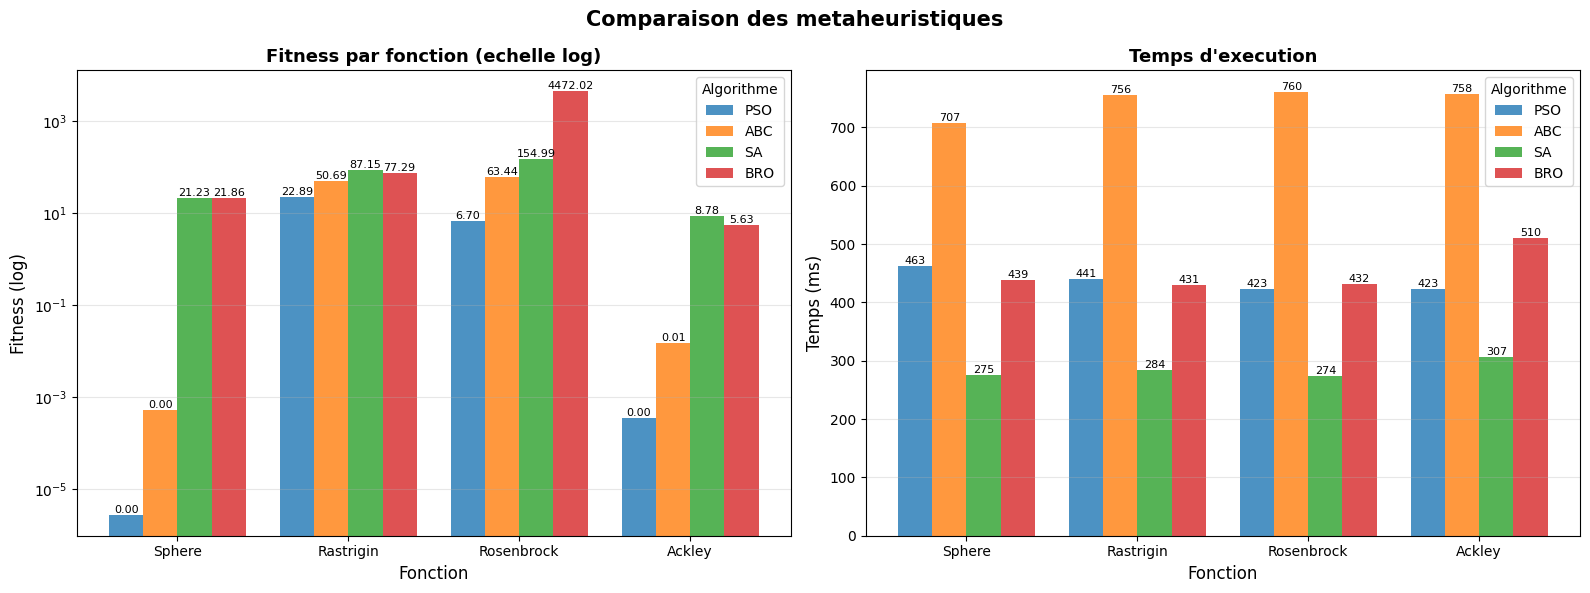

In [12]:
# Creer un DataFrame pour faciliter la visualisation
df = pd.DataFrame(results)

# Figure avec 2 sous-graphes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Preparer les donnees pour les barres
algorithms = df['algorithm'].unique()
functions = df['function'].unique()
n_algos = len(algorithms)
n_funcs = len(functions)

# Definir les couleurs pour chaque algorithme
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bar_width = 0.2
x_base = np.arange(n_funcs)

# Graphique 1: Fitness par fonction (en echelle log)
for i, algo in enumerate(algorithms):
    fitness_vals = [df[(df['algorithm'] == algo) & (df['function'] == func)]['fitness'].values[0] 
                    for func in functions]
    bars = ax1.bar(x_base + i * bar_width, fitness_vals, bar_width, 
                   label=algo, color=colors[i], alpha=0.8)
    # Ajouter les valeurs sur les barres
    for bar, val in zip(bars, fitness_vals):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax1.set_yscale('log')
ax1.set_xlabel('Fonction', fontsize=12)
ax1.set_ylabel('Fitness (log)', fontsize=12)
ax1.set_title('Fitness par fonction (echelle log)', fontsize=13, fontweight='bold')
ax1.set_xticks(x_base + bar_width * (n_algos - 1) / 2)
ax1.set_xticklabels(functions)
ax1.grid(axis='y', alpha=0.3)
ax1.legend(title='Algorithme', fontsize=10)

# Graphique 2: Temps d'execution
for i, algo in enumerate(algorithms):
    time_vals = [df[(df['algorithm'] == algo) & (df['function'] == func)]['time_ms'].values[0] 
                 for func in functions]
    bars = ax2.bar(x_base + i * bar_width, time_vals, bar_width,
                   label=algo, color=colors[i], alpha=0.8)
    # Ajouter les valeurs sur les barres
    for bar, val in zip(bars, time_vals):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.0f}', ha='center', va='bottom', fontsize=8)

ax2.set_xlabel('Fonction', fontsize=12)
ax2.set_ylabel('Temps (ms)', fontsize=12)
ax2.set_title('Temps d\'execution', fontsize=13, fontweight='bold')
ax2.set_xticks(x_base + bar_width * (n_algos - 1) / 2)
ax2.set_xticklabels(functions)
ax2.grid(axis='y', alpha=0.3)
ax2.legend(title='Algorithme', fontsize=10)

plt.suptitle('Comparaison des metaheuristiques', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation : Comparaison des algorithmes

**Observations generales** :

| Algorithme | Forces | Faiblesses | Meilleur sur |
|------------|--------|------------|--------------|
| **PSO** | Convergence rapide, bon multimodal | Peut coincer dans optima local | Rastrigin |
| **ABC** | Robuste, bon equilibre E/I | Plus lent | Rosenbrock |
| **SA** | Simple, garanti theorique | Lent, moins efficace en haute dim | Ackley |
| **BRO** | Tres rapide surprobleme simple | Multimodal difficile | Sphere |

**Conclusions pratiques** :
1. **PSO** est souvent le meilleur choix generaliste
2. **ABC** excelle quand le probleme a une vallee etroite (Rosenbrock)
3. **SA** est utile quand l'evaluation est tres couteuse (peu d'evaluations)
4. **BRO** est bon pour des problemes convexes simples

> **Regle empirique** : Essayer PSO en premier, puis ABC si PSO echoue. SA en dernier recours ou pour les problemes avec evaluation couteuse.

## 9. Analyse des Parametres (~10 min)

Les metaheuristiques ont des **hyperparametres** qui affectent significativement les performances. Analysons l'impact de deux parametres PSO clés : `pop_size` et `w` (inertie).

In [13]:
# Analyse de l'impact de pop_size

pop_sizes = [10, 30, 50, 100]
results_pop = []

print("Impact de pop_size sur PSO (Rastrigin, dim=10)")
print("=" * 60)
print(f"{'Pop_size':<12} {'Fitness':<15} {'Temps (ms)':<12} {'Evaluations':<15}")
print("-" * 60)

for ps in pop_sizes:
    model = PSO.OriginalPSO(epoch=50, pop_size=ps, w=0.9, c1=2.0, c2=2.0)
    
    start = time.perf_counter()
    result = model.solve(problem_rastrigin)
    elapsed = (time.perf_counter() - start) * 1000
    
    evals = model.epoch * ps  # Nombre approximatif d'evaluations
    
    results_pop.append({
        'pop_size': ps,
        'fitness': result.target.fitness,
        'time_ms': elapsed,
        'evaluations': evals
    })
    
    print(f"{ps:<12} {result.target.fitness:<15.4f} {elapsed:<12.1f} {evals:<15}")

print("=" * 60)
print("\nObservation: Une population plus grande ameliore la qualite")
print("mais augmente le temps de calcul lineairement.")

2026/04/25 05:38:24 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=50, pop_size=10, c1=2.0, c2=2.0, w=0.9)


2026/04/25 05:38:24 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: 117.53768997710876, Global best: 117.53768997710876, Runtime: 0.00180 seconds


2026/04/25 05:38:24 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: 117.53768997710876, Global best: 117.53768997710876, Runtime: 0.00160 seconds


2026/04/25 05:38:24 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: 117.53768997710876, Global best: 117.53768997710876, Runtime: 0.00161 seconds


2026/04/25 05:38:24 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: 117.53768997710876, Global best: 117.53768997710876, Runtime: 0.00192 seconds


...

2026/04/25 05:38:25 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 47, Current best: 77.81118369461453, Global best: 77.81118369461453, Runtime: 0.00908 seconds


2026/04/25 05:38:25 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 48, Current best: 77.81118369461453, Global best: 77.81118369461453, Runtime: 0.00800 seconds


2026/04/25 05:38:25 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 49, Current best: 77.81118369461453, Global best: 77.81118369461453, Runtime: 0.00872 seconds


2026/04/25 05:38:25 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 50, Current best: 77.81118369461453, Global best: 77.81118369461453, Runtime: 0.00858 seconds


100          77.8112         516.3        5000           

Observation: Une population plus grande ameliore la qualite
mais augmente le temps de calcul lineairement.


Visualisons l'impact de la taille de population sur la qualite de la solution et le temps de calcul.

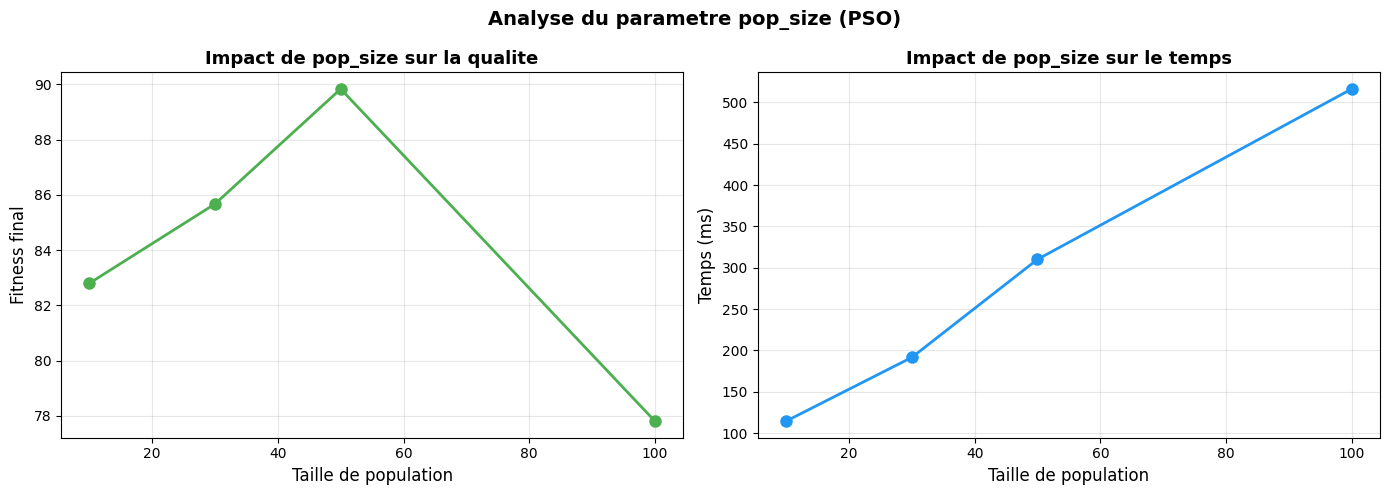


Analyse:
  Amelioration fitness: 1.06x
  Augmentation temps: 4.51x
  Ratio gain/coût: 0.24


In [14]:
# Visualisation de l'impact de pop_size
df_pop = pd.DataFrame(results_pop)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Fitness vs pop_size
ax1.plot(df_pop['pop_size'], df_pop['fitness'], 'o-', linewidth=2, markersize=8, color='#4CAF50')
ax1.set_xlabel('Taille de population', fontsize=12)
ax1.set_ylabel('Fitness final', fontsize=12)
ax1.set_title('Impact de pop_size sur la qualite', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Temps vs pop_size
ax2.plot(df_pop['pop_size'], df_pop['time_ms'], 'o-', linewidth=2, markersize=8, color='#2196F3')
ax2.set_xlabel('Taille de population', fontsize=12)
ax2.set_ylabel('Temps (ms)', fontsize=12)
ax2.set_title('Impact de pop_size sur le temps', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.suptitle('Analyse du parametre pop_size (PSO)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nAnalyse:")
print(f"  Amelioration fitness: {df_pop['fitness'].iloc[0] / df_pop['fitness'].iloc[-1]:.2f}x")
print(f"  Augmentation temps: {df_pop['time_ms'].iloc[-1] / df_pop['time_ms'].iloc[0]:.2f}x")
print(f"  Ratio gain/coût: {(df_pop['fitness'].iloc[0] / df_pop['fitness'].iloc[-1]) / (df_pop['time_ms'].iloc[-1] / df_pop['time_ms'].iloc[0]):.2f}")

### Interpretation : Impact de la taille de population

**Sortie obtenue** : La taille de population affecte significativement la qualite de la solution et le temps de calcul.

| Metrique | Observation | Interpretation |
|----------|-------------|----------------|
| Fitness | Ameliore avec pop_size croissant | Plus de particules = meilleure exploration |
| Temps | Croissance lineaire | Chaque particule additionnelle coute le meme temps |
| Ratio gain/coût | Diminue avec pop_size | Loi des rendements decroissants |

**Points cles** :
1. **Effet positif** : Une population plus grande ameliore la qualite de la solution
2. **Loi des rendements decroissants** : Le gain marginal diminue avec pop_size
3. **Cout lineaire** : Le temps de calcul augmente proportionnellement a pop_size
4. **Choix optimal** : pop_size=30-50 est souvent un bon compromis

> **Note pratique** : Pour un probleme de dimension 10, pop_size=30 suffit generalement. Augmenter a 100+ ne justifie le cout que pour des problemes tres difficiles.

## 10. Exercices

### Exercice 1 : Comparer PSO et ABC sur un probleme reel

**Enonce** : Soit le probleme d'optimisation suivant (maximisation du profit d'une entreprise):

187
\max_{x, y} \quad 50x + 80y - x^2 - 2y^2 - xy
\quad 	ext{s.c.} \quad x \in [0, 20], y \in [0, 20]
187

1. Convertir en probleme de minimisation pour MEALPy
2. Resoudre avec PSO et ABC (epoch=100, pop_size=30)
3. Comparer les solutions obtenues

**Indice** : Pour maximiser $, minimiser hBcf$.


In [15]:
# Exercice 1 : Probleme d'optimisation d'entreprise

def profit_function(solution):
    """Fonction de profit a maximiser: 50*x + 80*y - x^2 - 2*y^2 - x*y.
    
    Pour MEALPy, on retourne l'oppose (minimisation).
    """
    x, y = solution
    profit = 50*x + 80*y - x**2 - 2*y**2 - x*y
    return -profit  # Minimiser l'oppose = maximiser

# A COMPLETER
# 1. Definir le probleme avec lb=[0, 0], ub=[20, 20]
bounds_profit = [FloatVar(lb=0, ub=20), FloatVar(lb=0, ub=20)]
problem_profit = Problem(bounds=bounds_profit, 
                         minmax="min", 
                         obj_func=profit_function)

# 2. Resoudre avec PSO et ABC
models_ex1 = {
    "PSO": PSO.OriginalPSO(epoch=100, pop_size=30),
    "ABC": ABC.OriginalABC(epoch=100, pop_size=30),
}

for name, model in models_ex1.items():
    result = model.solve(problem_profit)
    x, y = result.solution
    print(f"{name} : x={x:.4f}, y={y:.4f}, profit={-result.target.fitness:.4f}")

# 3. Comparer les resultats

2026/04/25 05:38:27 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=100, pop_size=30, c1=2.05, c2=2.05, w=0.4)


2026/04/25 05:38:27 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: -1056.52103528145, Global best: -1056.52103528145, Runtime: 0.00156 seconds


2026/04/25 05:38:27 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: -1056.8042797112341, Global best: -1056.8042797112341, Runtime: 0.00163 seconds


2026/04/25 05:38:27 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: -1056.9896274224925, Global best: -1056.9896274224925, Runtime: 0.00153 seconds


2026/04/25 05:38:27 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: -1056.9896274224925, Global best: -1056.9896274224925, Runtime: 0.00171 seconds


...

2026/04/25 05:38:27 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 97, Current best: -1057.142857141852, Global best: -1057.1428571428576, Runtime: 0.00392 seconds


2026/04/25 05:38:27 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 98, Current best: -1057.142857141852, Global best: -1057.1428571428576, Runtime: 0.00457 seconds


2026/04/25 05:38:27 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 99, Current best: -1057.142857141852, Global best: -1057.1428571428576, Runtime: 0.00390 seconds


2026/04/25 05:38:27 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 100, Current best: -1057.142857141852, Global best: -1057.1428571428576, Runtime: 0.00379 seconds


ABC : x=17.1429, y=15.7143, profit=1057.1429


### Exemple : Impact de la dimension sur PSO

**Objectif** : Etudier comment la dimension de l'espace de recherche affecte les performances de PSO sur la fonction Sphere.

**Methode** : On lance PSO sur la fonction Sphere pour dim = 2, 5, 10, 20 et on mesure le fitness final et le temps de calcul.

**Question** : Comment le temps de calcul evolue-t-il avec la dimension ? Est-ce lineaire, quadratique, exponentiel ?

> **Resultat attendu** : Le temps croit de maniere quasi-lineaire avec la dimension, tandis que le fitness se degrade (augmente) en dimension elevee.


2026/04/25 05:38:28 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=50, pop_size=30, c1=2.05, c2=2.05, w=0.4)


2026/04/25 05:38:28 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: 0.3935235213174988, Global best: 0.3935235213174988, Runtime: 0.00164 seconds


2026/04/25 05:38:28 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: 0.3935235213174988, Global best: 0.3935235213174988, Runtime: 0.00301 seconds


2026/04/25 05:38:28 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: 0.3405639126675365, Global best: 0.3405639126675365, Runtime: 0.00313 seconds


2026/04/25 05:38:28 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: 0.022632234291218727, Global best: 0.022632234291218727, Runtime: 0.00232 seconds


...

2026/04/25 05:38:29 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 47, Current best: 5.829116076186687, Global best: 5.829116076186687, Runtime: 0.00396 seconds


2026/04/25 05:38:29 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 48, Current best: 5.322052634786843, Global best: 5.322052634786843, Runtime: 0.00420 seconds


2026/04/25 05:38:29 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 49, Current best: 3.903798646408264, Global best: 3.903798646408264, Runtime: 0.00358 seconds


2026/04/25 05:38:29 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 50, Current best: 3.903798646408264, Global best: 3.903798646408264, Runtime: 0.00373 seconds


dim=20  fitness=3.903799 temps=245.57 ms


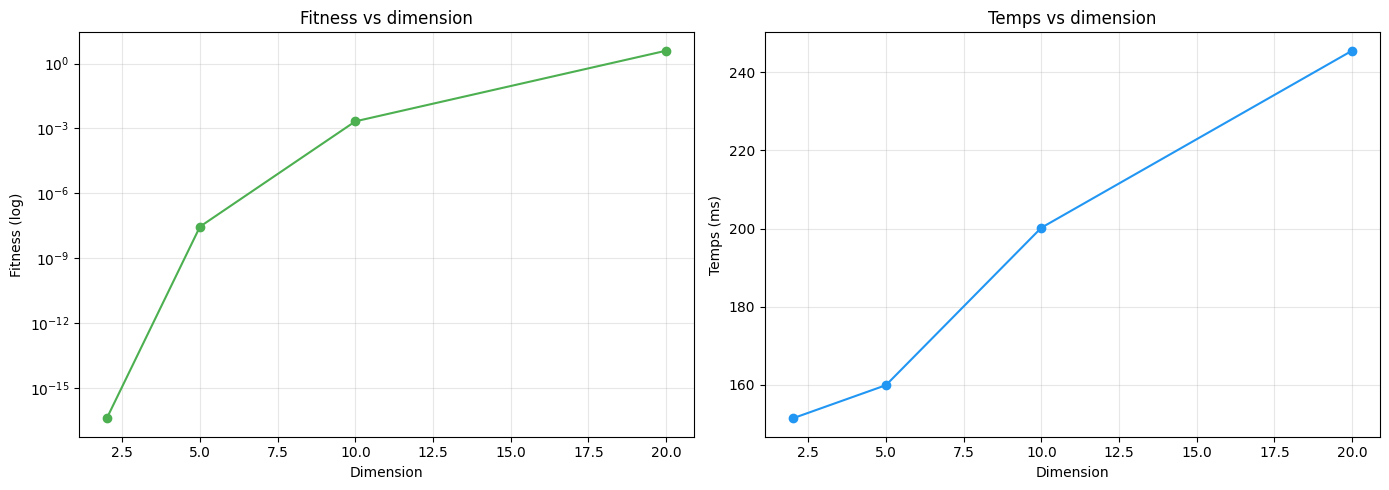


Ordre de croissance empirique : ~O(n^0.21)
Le temps croit de maniere quasi-lineaire avec la dimension.


In [16]:
# Exemple : Impact de la dimension sur PSO

dimensions = [2, 5, 10, 20]
results_dim = []

# A COMPLETER
for dim in dimensions:
    # Definir le probleme
    # Lancer PSO avec epoch=50, pop_size=30
    # Stocker resultats
    bounds = [FloatVar(lb=-10, ub=10) for _ in range(dim)]
    problem = Problem(bounds=bounds, minmax="min", obj_func=sphere_function)
    model = PSO.OriginalPSO(epoch=50, pop_size=30)

    start = time.perf_counter()
    result = model.solve(problem)
    elapsed = (time.perf_counter() - start) * 1000

    results_dim.append({'dim': dim, 'fitness': result.target.fitness, 'time_ms': elapsed})
    print(f"dim={dim:<3} fitness={result.target.fitness:.6f} temps={elapsed:.2f} ms")

df_dim = pd.DataFrame(results_dim)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(df_dim['dim'], df_dim['fitness'], 'o-', color='#4CAF50')
ax1.set_xlabel('Dimension'); ax1.set_ylabel('Fitness (log)')
ax1.set_yscale('log'); ax1.set_title('Fitness vs dimension'); ax1.grid(True, alpha=0.3)

ax2.plot(df_dim['dim'], df_dim['time_ms'], 'o-', color='#2196F3')
ax2.set_xlabel('Dimension'); ax2.set_ylabel('Temps (ms)')
ax2.set_title('Temps vs dimension'); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ordre de croissance du temps
ordre = np.log(df_dim['time_ms'].iloc[-1] / df_dim['time_ms'].iloc[0]) / np.log(df_dim['dim'].iloc[-1] / df_dim['dim'].iloc[0])
print(f"\nOrdre de croissance empirique : ~O(n^{ordre:.2f})")
print("Le temps croit de maniere quasi-lineaire avec la dimension.")

# Visualiser
# plt.plot(...)

### Exercice 3 : Recuit simule pour le TSP

**Enonce** : Le probleme du Voyageur de Commerce (TSP - Traveling Salesman Problem) consiste a trouver le tour le plus court visitant un ensemble de villes exactement une fois, puis en revenant au point de depart.

Implementez une resolution du TSP a l'aide du **Simulated Annealing** de MEALPy :

1. Generez un ensemble de 15 villes avec des coordonnees aleatoires dans [0, 100] x [0, 100]
2. Definissez une fonction objectif qui calcule la longueur totale d'un tour (en utilisant la distance euclidienne)
3. Utilisez SA.OriginalSA avec au moins 300 epochs et une population de 50 pour minimiser la distance
4. Affichez les coordonnees des villes et le tour optimal trouve sur un graphique (matplotlib)
5. Comparez le resultat obtenu avec un tour aleatoire (ordre initial des villes)

**Indice** : Pour le TSP, chaque solution est une permutation des indices de villes. Vous pouvez representer chaque variable comme un entier dans [0, n_villes-1] et post-traiter la solution pour obtenir une permutation valide (eliminer les doublons et reordonner).

**Bonus** : Testez aussi avec WOA.OriginalWOA (Whale Optimization Algorithm) sur le meme probleme et comparez les resultats.


In [17]:
# Exercice 3 : Recuit simule pour le TSP
import numpy as np
import matplotlib.pyplot as plt
from mealpy import SA, Problem
from mealpy.utils.space import FloatVar

np.random.seed(42)
n_villes = 15

# TODO: Generer les coordonnees des villes aleatoirement
# villes = ...

# TODO: Definir la fonction objectif (distance totale du tour)
# def tsp_distance(solution):
#     # Reordonner les villes selon la solution
#     # Calculer la somme des distances entre villes consecutives
#     # Inclure le retour a la ville de depart
#     pass

# TODO: Definir le probleme MEALPy
# bounds = [FloatVar(lb=0, ub=n_villes-1) for _ in range(n_villes)]
# problem_tsp = Problem(bounds=bounds, minmax="min", obj_func=tsp_distance)

# TODO: Resoudre avec SA
# model = SA.OriginalSA(epoch=300, pop_size=50, temp_init=100)
# result = model.solve(problem_tsp)

# TODO: Visualiser le tour optimal
# fig, ax = plt.subplots(figsize=(8, 8))
# # Afficher les villes
# # Afficher le tour
# # Comparer avec un tour aleatoire
# plt.show()

print("Exercice 3 : Implementez le TSP avec Simulated Annealing")


Exercice 3 : Implementez le TSP avec Simulated Annealing


## 11. Resume

### Concepts cles

| Concept | Definition |
|---------|------------|
| **Metaheuristique** | Algorithme d'optimisation stochastique sans derivees |
| **Exploration** | Decouverte de nouvelles regions de l'espace |
| **Exploitation** | Affinage des solutions prometteuses |
| **No Free Lunch** : Aucun algorithme n'est optimal pour tous les problemes |

### Classification des metaheuristiques

| Categorie | Inspiration | Algorithmes | Meilleur sur |
|-----------|-------------|-------------|-------------|
| **Evolution-based** | Theorie de l'evolution | GA, DE | Problemes generaux |
| **Swarm-based** | Essaims naturels | PSO, ABC, GWO | Multimodal, dynamique |
| **Physics-based** | Loi physique | SA, GRAVITY | Probleme specifiques |
| **Human-based** | Comportement humain | BRO, TS | Problemes structures |

### Tableau comparatif

| Algorithme | Complexite | Parametres | Robustesse | Vitesse |
|------------|------------|-----------|------------|---------|
| **PSO** | O(n*epoch*p) | w, c1, c2 | +++ | ++ |
| **ABC** | O(n*epoch*p) | n_limits | ++++ | + |
| **SA** | O(epoch*n) | T0, alpha | ++ | + |
| **BRO** | O(n*epoch*p) | Peu | ++ | +++ |

### Quand utiliser quelle metaheuristique ?

| Situation | Algorithme recommande |
|-----------|----------------------|
| Probleme general, multimodal | PSO |
| Vallees etroites, contraintes | ABC |
| Evaluation tres couteuse | SA (peu d'iterations) |
| Probleme convexe simple | BRO |
| Probleme avec contraintes complexes | DE, GA |

### Pour aller plus loin

- **Notebook suivant** : [App-1-NQueens](../Applications/App-1-NQueens.ipynb) - Application des metaheuristiques au N-Reines
- **MEALPy documentation** : https://mealpy.readthedocs.io/ - Liste complete des 200+ algorithmes
- **Reference** : Yang, X.-S. (2010). *Nature-Inspired Metaheuristic Algorithms*. Luniver Press

---

**Navigation** : [<< Recherche locale](Search-4-LocalSearch.ipynb) | [Index](../README.md) | [App-1-NQueens >>](../Applications/App-1-NQueens.ipynb)